# Estimation: From Historical Data to Future Dynamics

> "It is a capital mistake to theorize before one has data"

---

We estimate four objects, in order: **betas → variances → factor risk premia → alpha**

## Learning Objectives

1. Historical data is informative about the future — but only for *some* quantities
2. Factor models separate what data can estimate well from what it cannot
3. **Betas and variances**: estimable. **Means**: hard. **Alpha**: very hard.
4. This chapter is "stats" — but it is at the core of quant investing

In [1]:
# %pip install wrds          # uncomment on first Colab run, then restart
# import wrds                # uncomment after restart

import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import pandas_datareader.data as DataReader
import statsmodels.api as sm
from scipy.stats import norm

# ── helper: pull daily returns from WRDS ──
def get_daily_wrds(conn, tickers=None):
    permnos = conn.get_table(library='crsp', table='stocknames',
                             columns=['permno','ticker','namedt','nameenddt'])
    permnos['nameenddt'] = pd.to_datetime(permnos['nameenddt'])
    permnos = permnos[(permnos['ticker'].isin(tickers)) &
                      (permnos['nameenddt'] == permnos['nameenddt'].max())]
    permno_list = permnos['permno'].unique().tolist()
    query = f"""
        SELECT permno, date, ret, retx, prc
        FROM crsp.dsf
        WHERE permno IN ({','.join(map(str, permno_list))})
        ORDER BY date, permno
    """
    df = conn.raw_sql(query, date_cols=['date'])
    df = df.merge(permnos[['permno','ticker']], on='permno', how='left')
    df = df.pivot(index='date', columns='ticker', values='ret')[tickers]
    return df

# ── helper: Fama-French factors ──
def get_factors(factors='CAPM'):
    if factors == 'CAPM':
        d = DataReader.DataReader("F-F_Research_Data_Factors_daily","famafrench",start="1921-01-01")[0]
        cols = ['RF','Mkt-RF']
    elif factors == 'FF3':
        d = DataReader.DataReader("F-F_Research_Data_Factors_daily","famafrench",start="1921-01-01")[0]
        cols = ['RF','Mkt-RF','SMB','HML']
    elif factors == 'FF5':
        d = DataReader.DataReader("F-F_Research_Data_5_Factors_2x3_daily","famafrench",start="1921-01-01")[0]
        cols = ['RF','Mkt-RF','SMB','HML','RMW','CMA']
    else:
        d = DataReader.DataReader("F-F_Research_Data_5_Factors_2x3_daily","famafrench",start="1921-01-01")[0]
        cols = ['RF','Mkt-RF','SMB','HML','RMW','CMA']
        mom = DataReader.DataReader("F-F_Momentum_Factor_daily","famafrench",start="1921-01-01")[0]
        d = d.merge(mom, on='Date')
    d.index = pd.to_datetime(d.index)
    return d[cols] / 100

## Factor Model Recap

**Realized returns:** $\; r = r_f + \alpha + \beta\,(f - r_f) + \varepsilon$

**Expected excess returns:** $\; E[r^e] = \alpha + \beta \cdot E[f]$

**Variance:** $\; \text{Var}(r) = \beta^2\,\text{Var}(f) + \text{Var}(\varepsilon)$

| Parameter | Source |
|-----------|--------|
| Risk-free rate $r_f$ | Observed directly (bond markets) |
| Beta $\beta$ | Estimated from historical co-movement |
| Factor premium $E[f]$ | Estimated from long historical averages |
| Alpha $\alpha$ | **Not reliably estimated** — requires judgment |
| Factor & idio variance | Estimated from historical returns |

## What Problem Are We Solving?

- Do we care how a stock behaved in the past? **No.**
- We care about historical data **only** when it helps predict what happens *next*
- Some quantities are stable enough that the past is informative (betas, variances)
- Others are not (alpha)
- Factor models help us separate the two

---

We discuss each estimation problem one-by-one: **betas → variances → premia → alpha**

## Betas (Factor Loadings)

Beta = forward-looking co-movement between an asset and the factor:

$$\beta_t = \frac{\text{Cov}_t(r^e_{t+1},\, f_{t+1})}{\text{Var}_t(f_{t+1})}$$

- $\beta = 1$: moves one-for-one with the factor
- $\beta = 2$: market drops 1% → stock drops 2%
- Subscript $t$: conditional on *today's* information (no crystal ball)

### Data: GE excess returns vs the market

In [2]:
# ── Load pre-saved data (or uncomment WRDS block) ──
# conn = wrds.Connection()
# tickers = ['GE']
# df = get_daily_wrds(conn, tickers)
# df.to_csv('../../assets/data/FactorModelsEstimation_data1.csv')

df = pd.read_csv('https://raw.githubusercontent.com/amoreira2/UG54/refs/heads/main/assets/data/FactorModelsEstimation_data1.csv')
df.date = pd.to_datetime(df.date)
df.set_index('date', inplace=True)

df_factor = get_factors()
df, df_factor = df.dropna().align(df_factor.dropna(), join='inner', axis=0)
tickers = ['GE']
df_re = df[tickers].sub(df_factor['RF'], axis=0)

display(df_re.head())
display(df_re.tail())

/var/folders/ft/hpl8ntq506jgz116vbqnwqj40000gp/T/ipykernel_70085/1804141976.py:34: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  d = DataReader.DataReader("F-F_Research_Data_Factors_daily","famafrench",start="1921-01-01")[0]


,GE
1926-07-01,-0.000100
1926-07-02,-0.000100
1926-07-06,0.007210
1926-07-07,-0.000100
1926-07-08,0.004254


,GE
2024-12-24,0.014414
2024-12-26,0.003649
2024-12-27,-0.010598
2024-12-30,-0.011842
2024-12-31,-0.007993


### Estimating Beta: OLS Regression

- Regress excess returns on the factor — the slope is $\beta$
- **Look-back window matters**: too long → stale; too short → noisy
- Rule of thumb: **1–2 years of daily data** for individual stocks
- For illiquid stocks use weekly/monthly with longer windows (e.g., 5 years monthly)

In [3]:
X = sm.add_constant(df_factor['Mkt-RF'])
y = df_re['GE']
model = sm.OLS(y, X).fit()
display(model.summary())

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     GE   R-squared:                       0.546
Model:                            OLS   Adj. R-squared:                  0.546
Method:                 Least Squares   F-statistic:                 3.119e+04
Date:                Mon, 02 Mar 2026   Prob (F-statistic):               0.00
Time:                        09:25:58   Log-Likelihood:                 77611.
No. Observations:               25898   AIC:                        -1.552e+05
Df Residuals:                   25896   BIC:                        -1.552e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.608e-05   7.51e-05      0.347      0.728      -0.000       0.000
Mkt-RF         1.2317      0.007    176.613      0.000       1.218       1.245
==============================================================================
Omnibus:                     5521.912   Durbin-Watson:                   2.092
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           136800.865
Skew:                           0.426   Prob(JB):                         0.00
Kurtosis:                      14.227   Cond. No.                         92.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Question G1

Complete the code below and be prepared to answer the questions.

In [ ]:
#1. How well is estimated? Recover the standard error
print(model.__)
#2. Given this, how well it is estimated?
#3. Based on this how confident we are that the beta is more than 1? (qualitative)
#4. How much uncertainty do we have about it? 95% confidence interval?
print([model.__['Mkt-RF'] + 1.96*model.__['Mkt-RF'],
       model.__['Mkt-RF'] - 1.96*model.__['Mkt-RF']])
#5. How do I adjust the t-statistic to test if beta is greater than 1?
tstat = (model.__['Mkt-RF'] - __) / model.__['Mkt-RF']
print(tstat)
#6. Probability that beta > 1? And < 1?
probmorethan1 = __ - norm.__(tstat)
print(probmorethan1)

### Betas Change Over Time

- Almost always above 1, but all over the place
- Are these real shifts, or just estimation noise?
- What does the spike around 2008–09 tell us?

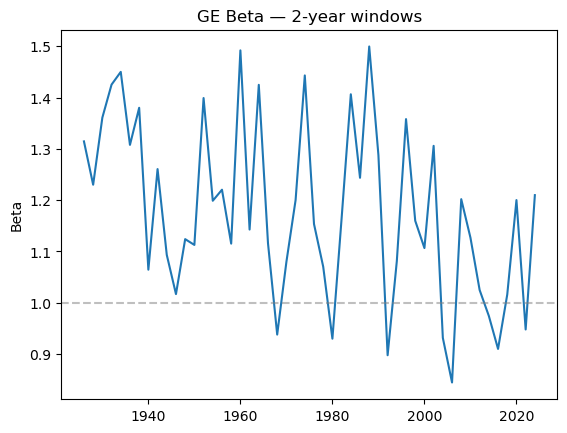

In [4]:
# Merge factor and excess returns
df_m = df_factor.copy()
df_m['re'] = df_re['GE']

def regression_beta(df):
    X = sm.add_constant(df['Mkt-RF'])
    y = df['re']
    return sm.OLS(y, X).fit(dropna=True).params['Mkt-RF']

df_m.groupby((df_m.index.year // 2) * 2).apply(regression_beta).plot(
    title='GE Beta — 2-year windows')
plt.ylabel('Beta')
plt.axhline(1, color='grey', linestyle='--', alpha=0.5)
plt.show()

### Uncertainty Around Beta Estimates

- Point estimates bounce around — but how much is real vs noise?
- Standard errors tell us: given *this* data window, what range of $\beta$ is consistent?
- But we need $\beta$ for *next* period — within-sample precision ≠ out-of-sample accuracy

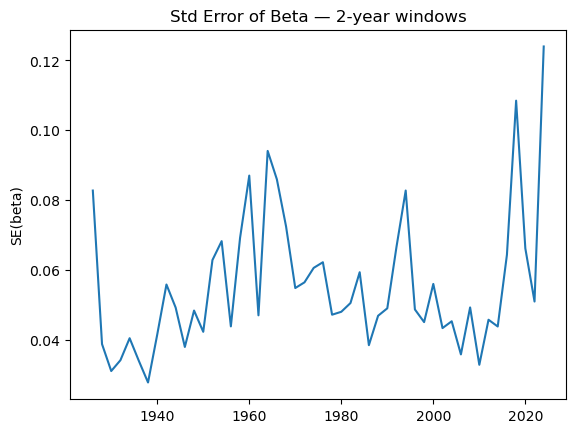

In [5]:
# Standard errors per 2-year window
se = df_m.groupby((df_m.index.year // 2) * 2).apply(
    lambda x: sm.OLS(x['re'], sm.add_constant(x['Mkt-RF'])).fit().bse['Mkt-RF'])
se.plot(title='Std Error of Beta — 2-year windows')
plt.ylabel('SE(beta)')
plt.show()

### Confidence Intervals

$\text{95\% CI} = \hat\beta \pm 1.96 \times \text{SE}$

**Question G2:** How do you turn this into a function that takes (a) window length and (b) CI level as inputs?

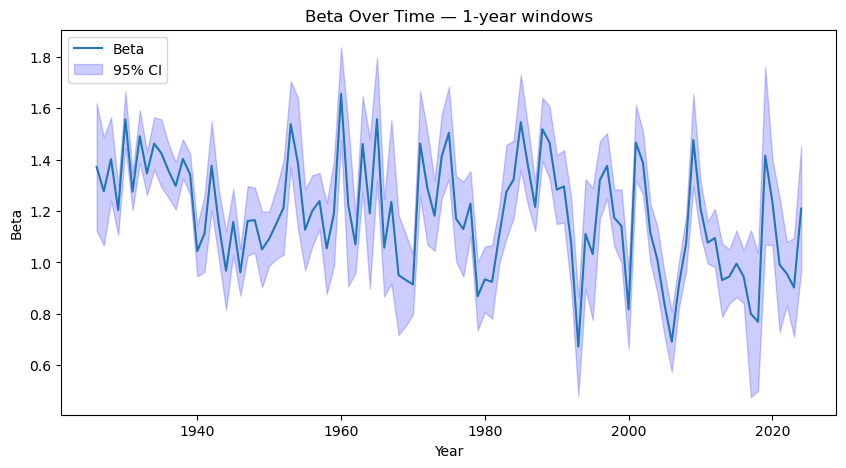

In [6]:
y_win = 1  # change to 2, 5, 10 to see the effect
grp = (df_m.index.year // y_win) * y_win
se = grp.map(df_m.groupby(grp).apply(
    lambda x: sm.OLS(x['re'], sm.add_constant(x['Mkt-RF'])).fit().bse['Mkt-RF']))
e  = grp.map(df_m.groupby(grp).apply(
    lambda x: sm.OLS(x['re'], sm.add_constant(x['Mkt-RF'])).fit().params['Mkt-RF']))

# deduplicate to one point per window
e_plot  = df_m.groupby(grp).apply(lambda x: sm.OLS(x['re'], sm.add_constant(x['Mkt-RF'])).fit().params['Mkt-RF'])
se_plot = df_m.groupby(grp).apply(lambda x: sm.OLS(x['re'], sm.add_constant(x['Mkt-RF'])).fit().bse['Mkt-RF'])

plt.figure(figsize=(10, 5))
plt.plot(e_plot.index, e_plot, label='Beta')
plt.fill_between(e_plot.index, e_plot - 1.96*se_plot, e_plot + 1.96*se_plot,
                 color='b', alpha=0.2, label='95% CI')
plt.xlabel('Year'); plt.ylabel('Beta')
plt.title(f'Beta Over Time — {y_win}-year windows')
plt.legend(); plt.show()

### Beta Is a Forecasting Problem

- In-sample CIs tell you about *this* window's beta
- But you need beta for *next* period
- So: does past beta predict future beta?

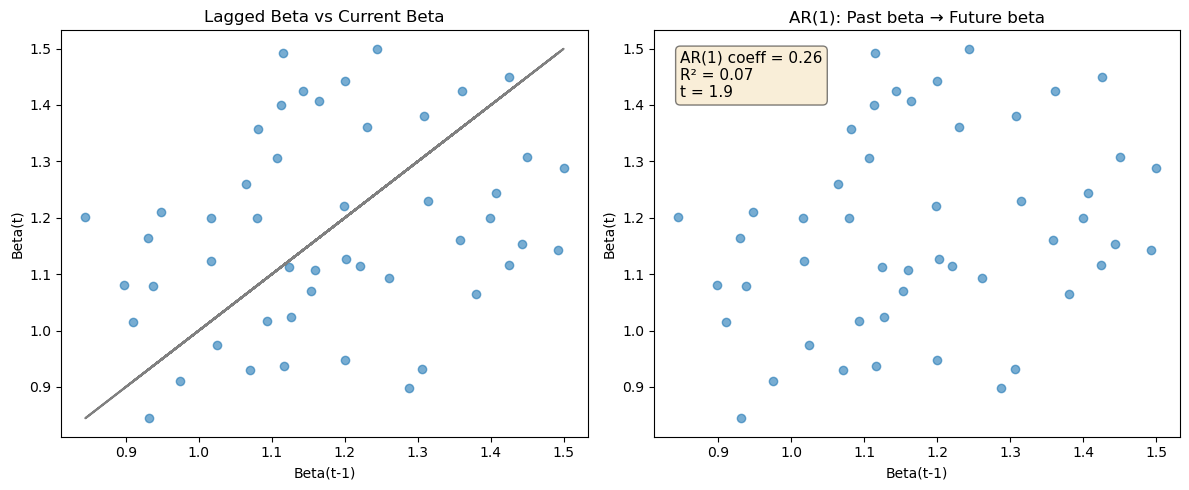

In [7]:
e = df_m.groupby((df_m.index.year // 2) * 2).apply(regression_beta)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# scatter: lagged vs current
axes[0].scatter(e.shift(1), e, alpha=0.6)
axes[0].plot(e.shift(1), e.shift(1), '-', color='grey')
axes[0].set_xlabel('Beta(t-1)'); axes[0].set_ylabel('Beta(t)')
axes[0].set_title('Lagged Beta vs Current Beta')

# AR(1) regression
reg = sm.OLS(e[1:], sm.add_constant(e.shift(1)[1:])).fit()
axes[1].text(0.05, 0.95, f"AR(1) coeff = {reg.params.iloc[1]:.2f}\n"
             f"R² = {reg.rsquared:.2f}\nt = {reg.tvalues.iloc[1]:.1f}",
             transform=axes[1].transAxes, va='top', fontsize=11,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
axes[1].scatter(e.shift(1), e, alpha=0.6)
axes[1].set_xlabel('Beta(t-1)'); axes[1].set_ylabel('Beta(t)')
axes[1].set_title('AR(1): Past beta → Future beta')

plt.tight_layout(); plt.show()

### Alternative: Exponential Decay Weighting

Instead of a hard window, put smoothly declining weights on older data:

$$W_t = \frac{e^{-\delta(T-t)}}{\sum_s e^{-\delta(T-s)}}$$

Run WLS instead of OLS — recent observations count more.

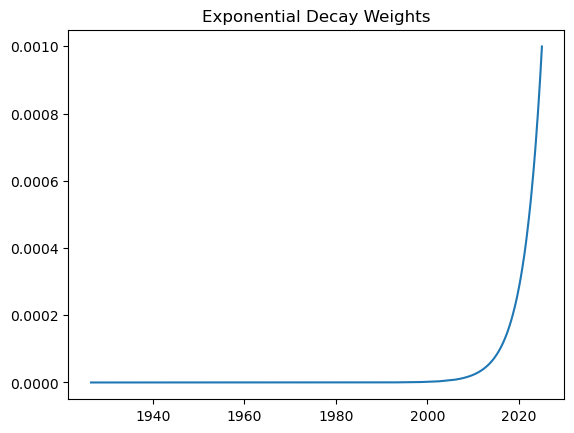

<class 'statsmodels.iolib.summary.Summary'>
"""
                            WLS Regression Results                            
==============================================================================
Dep. Variable:                     re   R-squared:                       0.332
Model:                            WLS   Adj. R-squared:                  0.332
Method:                 Least Squares   F-statistic:                 1.285e+04
Date:                Mon, 02 Mar 2026   Prob (F-statistic):               0.00
Time:                        09:26:18   Log-Likelihood:                -57752.
No. Observations:               25898   AIC:                         1.155e+05
Df Residuals:                   25896   BIC:                         1.155e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0003      0.000      3.007      0.003       0.000       0.001
Mkt-RF         1.0792      0.010    113.372      0.000       1.061       1.098
==============================================================================
Omnibus:                    14270.716   Durbin-Watson:                   2.053
Prob(Omnibus):                  0.000   Jarque-Bera (JB):          9012959.432
Skew:                           1.276   Prob(JB):                         0.00
Kurtosis:                      94.356   Cond. No.                         86.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [8]:
X = sm.add_constant(df_m['Mkt-RF'])
y = df_m['re']
n = len(y)
decay_rate = 0.001

weights = np.exp(-decay_rate * np.arange(n)[::-1])
weights /= weights.sum()
plt.plot(df_m.index, weights)
plt.title('Exponential Decay Weights'); plt.show()

results = sm.WLS(y, X, weights=weights).fit()
display(results.summary())

## Variances

Two flavors: **factor variance** and **idiosyncratic variance**

- Both cluster at high frequency (days → months)
- For horizons > 1 year, long-run averages suffice
- For horizons < 1 month, you need high-frequency models

Average market vol ≈ **17%/year** — but peak crisis vol can be **3× higher**

Full-sample annualized market vol: 17.1%


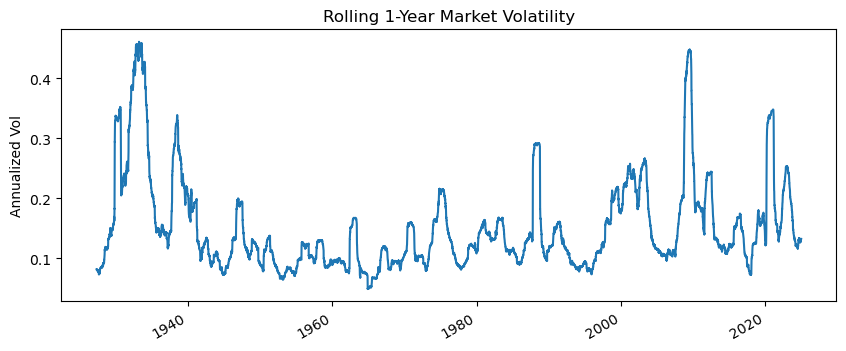

In [9]:
print(f"Full-sample annualized market vol: {df_m['Mkt-RF'].std()*252**0.5:.1%}")

fig, ax = plt.subplots(figsize=(10, 4))
(df_m['Mkt-RF'].rolling(252).std() * 252**0.5).plot(ax=ax)
ax.set_ylabel('Annualized Vol'); ax.set_title('Rolling 1-Year Market Volatility')
plt.show()

### Realized Variance

Rob Engle won the **Nobel Prize** for models that forecast volatility (ARCH/GARCH).

We use a simpler approach: monthly realized variance from daily data:

$$RV_t = \sum_{d \in \text{month } t} \frac{(r_d - \bar{r})^2}{N_{\text{days}}}$$

Non-overlapping — no artificial smoothness from shared data.

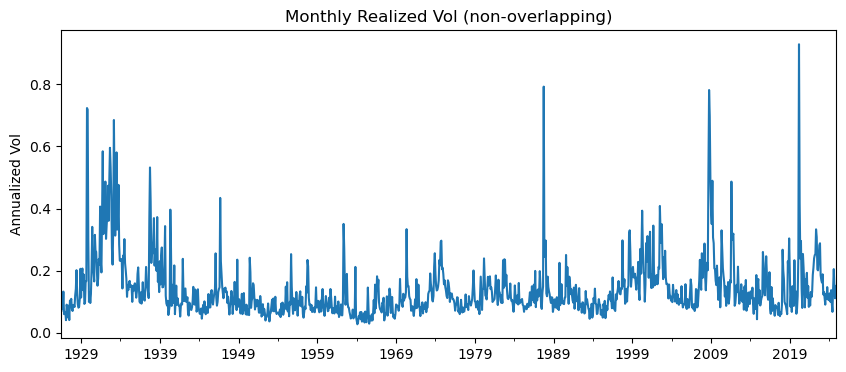

In [10]:
df_var = df_m.groupby(df_m.index + pd.offsets.MonthEnd(0)).apply(
    lambda x: x['Mkt-RF'].var() * 252)

fig, ax = plt.subplots(figsize=(10, 4))
(df_var**0.5).plot(ax=ax)
ax.set_ylabel('Annualized Vol'); ax.set_title('Monthly Realized Vol (non-overlapping)')
plt.show()

### Forecasting Realized Variance

Volatility is **persistent** — past vol predicts future vol.

Simple AR(1): $\; RV_{t+1} = a + b\,RV_t + \varepsilon_{t+1}$

In [11]:
df_var_lag = df_var.shift(1)
X = sm.add_constant(df_var_lag[1:])
y = df_var[1:]
model_rv = sm.OLS(y, X).fit()
print(model_rv.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.291
Model:                            OLS   Adj. R-squared:                  0.290
Method:                 Least Squares   F-statistic:                     483.1
Date:                Mon, 02 Mar 2026   Prob (F-statistic):           5.18e-90
Time:                        09:26:28   Log-Likelihood:                 1878.6
No. Observations:                1181   AIC:                            -3753.
Df Residuals:                    1179   BIC:                            -3743.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0132      0.002      8.266      0.0

### VIX: The Market's Variance Forecast

- The VIX is derived from S&P 500 option prices
- It equals the *risk-neutral expectation* of next-30-day variance
- If your own variance forecast < VIX² → sell variance (or buy stocks)
- If your own forecast > VIX² → buy variance (or reduce exposure)

Does VIX subsume past realized variance?

In [12]:
vix = DataReader.DataReader("VIXCLS", "fred",
                            start=df_var.index.min(), end=df_var.index.max())
vix = vix.resample('M').last()

df_vv = df_var.to_frame('rv').join((vix/100)**2, how='inner')
df_vv['VIX_lag'] = df_vv['VIXCLS'].shift(1)
df_vv['rv_lag']  = df_vv['rv'].shift(1)
df_vv = df_vv.dropna()

model_vix = sm.OLS(df_vv['rv'], sm.add_constant(df_vv[['rv_lag','VIX_lag']])).fit()
print(model_vix.summary())

                            OLS Regression Results                            
Dep. Variable:                     rv   R-squared:                       0.380
Model:                            OLS   Adj. R-squared:                  0.377
Method:                 Least Squares   F-statistic:                     127.6
Date:                Mon, 02 Mar 2026   Prob (F-statistic):           6.28e-44
Time:                        09:26:48   Log-Likelihood:                 653.79
No. Observations:                 419   AIC:                            -1302.
Df Residuals:                     416   BIC:                            -1289.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0089      0.004     -2.229      0.0

/var/folders/ft/hpl8ntq506jgz116vbqnwqj40000gp/T/ipykernel_70085/3078549407.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  vix = vix.resample('M').last()


### Idiosyncratic Volatility

$\varepsilon = r^e - (\alpha + \beta f)$ &emsp;→&emsp; $\text{Var}(\varepsilon) = \text{Var}(r^e - \beta f)$

Depends on your beta estimate. Here we fix $\beta$ at the full-sample value.

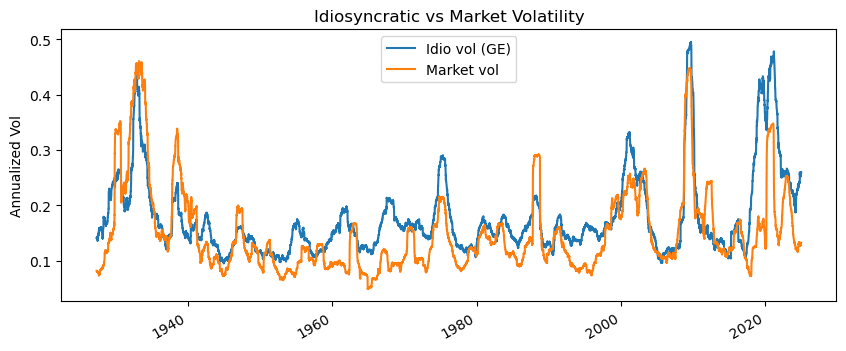

In [13]:
df_m = df_m.dropna()
model_full = sm.OLS(df_m['re'], sm.add_constant(df_m['Mkt-RF'])).fit(dropna=True)
df_m['e'] = model_full.resid

fig, ax = plt.subplots(figsize=(10, 4))
(df_m['e'].rolling(252).std()  * 252**0.5).plot(ax=ax, label='Idio vol (GE)')
(df_m['Mkt-RF'].rolling(252).std() * 252**0.5).plot(ax=ax, label='Market vol')
ax.legend(); ax.set_ylabel('Annualized Vol')
ax.set_title('Idiosyncratic vs Market Volatility')
plt.show()

### Question G3

- How would you estimate idio vol using the *Realized Variance* (non-overlapping) approach?
- What model(s) would you try to *forecast* idio vol? Be concrete.

## Expected Returns

$$E[r] = r_f + \alpha + \beta \cdot E[f]$$

Three pieces:
1. **Risk-free rate** — observed directly in bond markets
2. **Factor risk premia** — stable, estimated from long samples
3. **Alpha** — transient, cannot be reliably estimated from data

### Factor Risk Premia

- Compensation for *systematic* risk — doesn't vanish because investors know about it
- More stable than alpha → comfortable using **long** samples
- Best estimate (if constant): sample mean of the longest available history

$$\hat{E}[r^e] = \frac{1}{T}\sum_{t=1}^T r^e_t, \qquad \text{SE} = \frac{\sigma(r^e)}{\sqrt{T}}$$

In [14]:
mu  = df_m['Mkt-RF'].mean() * 252
sig = df_m['Mkt-RF'].std() * 252**0.5
T   = len(df_m) / 252
se  = sig / T**0.5

print(f"Market premium:  {mu:.1%}")
print(f"Market vol:      {sig:.1%}")
print(f"SE of mean:      {se:.1%}")
print(f"t-stat (H0=0):   {mu/se:.2f}")

Market premium:  7.7%
Market vol:      17.1%
SE of mean:      1.7%
t-stat (H0=0):   4.58


### "Only Time Will Tell"

Sampling more *frequently* does **not** improve precision of expected return estimates.

Both mean and variance scale with frequency — the ratio stays the same.

$\text{SE} = \sigma / \sqrt{T}$ depends on **calendar time** $T$, not number of observations.

In [16]:
nullh = 0.03
t = (mu - nullh) / se
p = (1 - norm.cdf(t)) * 100
print(f"t-stat (H0 = {nullh:.0%}): {t:.2f}")
print(f"Prob market premium < {nullh:.0%}: {p:.1f}%")

t-stat (H0 = 3%): 2.80
Prob market premium < 3%: 0.3%


### How Long to Detect a Positive Premium?

Need $t > 1.64$ for 95% one-sided confidence:

$$T = 1.64^2 \times \left(\frac{E[r^e]}{\sigma(r^e)}\right)^{-2} = 1.64^2 \times SR^{-2}$$

The term $E[r^e]/\sigma$ is the **Sharpe ratio**. Lower SR → need more years.

In [15]:
sr = mu / sig
T_needed = norm.ppf(0.95)**2 / sr**2
print(f"Sharpe ratio:   {sr:.2f}")
print(f"Years needed:   {T_needed:.0f}")

Sharpe ratio:   0.45
Years needed:   13


### Question G4

1. What does ~13 years imply for someone opening a hedge fund? Think about the investor's problem.
2. Why does this make high-SR strategies *extra* valuable for pod shops?

### Can We Detect Time-Variation in the Premium?

Split into 15-year windows (roughly the minimum to clear $t > 1.64$).

- Many windows fail to reach 95% confidence
- If the premium moves faster than 15 years, the sample mean is a poor estimator
- Timing the market from past returns — even 15 years — is very hard

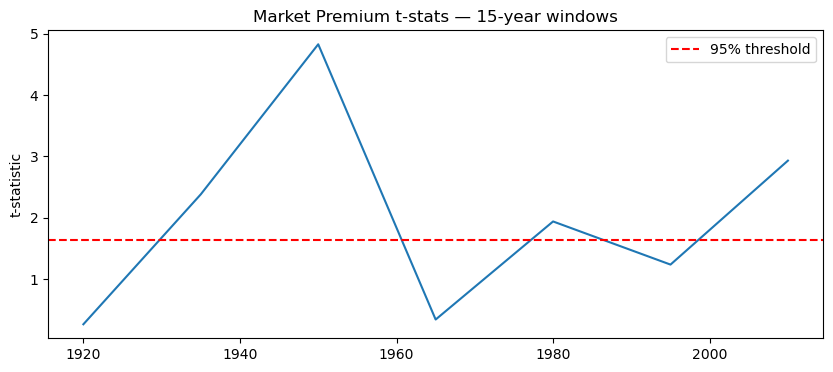

In [17]:
y = 15
tstats = df_m.groupby((df_m.index.year // y) * y).apply(
    lambda x: x['Mkt-RF'].mean() / (x['Mkt-RF'].std() / x['Mkt-RF'].count()**0.5))

fig, ax = plt.subplots(figsize=(10, 4))
tstats.plot(ax=ax)
ax.axhline(1.64, color='r', linestyle='--', label='95% threshold')
ax.legend(); ax.set_ylabel('t-statistic')
ax.set_title('Market Premium t-stats — 15-year windows')
plt.show()

### Forecasting Market Returns — Literature

Many signals have been tried:
- Past volatility (doesn't work)
- Dividend yield, earnings yield (maybe, unreliable)
- Variance risk premium (VIX minus past vol — works somewhat, short sample)
- Share issuance

All boil down to: $\; r_{t+1} = a + b\,X_t + \varepsilon_{t+1}$

It is very tricky business. We return to this in the **timing lecture**.

## Alpha: The Holy Grail

$$\alpha = E[r^e - \beta f]$$

- Alpha is the expected return of the *hedged* portfolio
- Unlike factor premia, alpha is **transient**: everyone chases it, so it disappears
- You cannot reliably estimate it from data — you need an **edge**

/var/folders/ft/hpl8ntq506jgz116vbqnwqj40000gp/T/ipykernel_70085/1804141976.py:34: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  d = DataReader.DataReader("F-F_Research_Data_Factors_daily","famafrench",start="1921-01-01")[0]


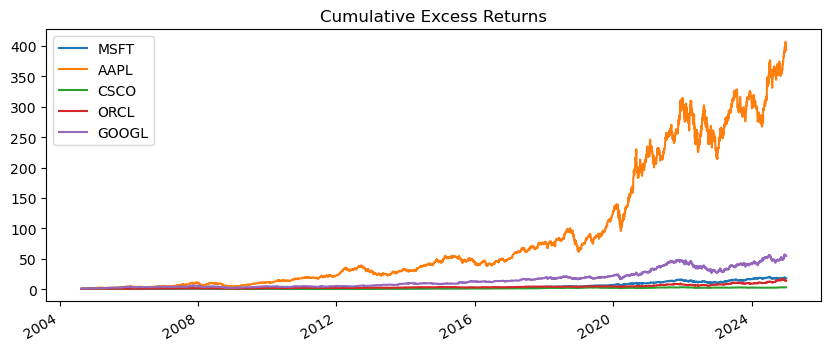

In [18]:
# ── Load multi-stock data ──
# conn = wrds.Connection()
# tickers = ['MSFT','AAPL','CSCO','ORCL','GOOGL']
# df = get_daily_wrds(conn, tickers).dropna()
# df.to_csv('../../assets/data/FactorModelsEstimation_data2.csv')

df = pd.read_csv('https://raw.githubusercontent.com/amoreira2/UG54/refs/heads/main/assets/data/FactorModelsEstimation_data2.csv')
df.date = pd.to_datetime(df.date)
df.set_index('date', inplace=True)

df_factor = get_factors()
df, df_factor = df.align(df_factor, join='inner', axis=0)
df_re = df.subtract(df_factor['RF'], axis=0)

(1 + df_re).cumprod().plot(title='Cumulative Excess Returns', figsize=(10, 4))
plt.show()

### Estimating Alpha Across Stocks

- Estimate $\alpha$ in 1-year windows for each stock
- Then ask: does past $\alpha$ predict future $\alpha$?

In [19]:
period_length = 1
results_dict = {'Ticker': [], 'Period': [], 'Alpha': [], 'Alpha_SE': [], 'Alpha_Tstat': []}

for start_year in range(df_re.index.year.min(), df_re.index.year.max(), period_length):
    end_year = start_year + period_length - 1
    mask = (df_re.index.year >= start_year) & (df_re.index.year <= end_year)
    df_re_p   = df_re[mask]
    df_fac_p  = df_factor[mask]

    for ticker in df_re.columns:
        try:
            y = df_re_p[ticker]
            X = sm.add_constant(df_fac_p['Mkt-RF'])
            m = sm.OLS(y, X, missing='drop').fit()
            results_dict['Ticker'].append(ticker)
            results_dict['Period'].append(end_year)
            results_dict['Alpha'].append(m.params['const'] * 252)
            results_dict['Alpha_SE'].append(m.bse['const'] * 252)
            results_dict['Alpha_Tstat'].append(m.params['const'] / m.bse['const'])
        except:
            pass

results_df = pd.DataFrame(results_dict)
print(results_df)

   Ticker  Period     Alpha  Alpha_SE  Alpha_Tstat
0    MSFT    2004 -0.034329  0.173273    -0.198122
1    AAPL    2004  1.804751  0.695194     2.596038
2    CSCO    2004 -0.462225  0.381393    -1.211939
3    ORCL    2004  0.330323  0.490510     0.673428
4   GOOGL    2004  1.865736  0.880351     2.119310
..    ...     ...       ...       ...          ...
95   MSFT    2023  0.229256  0.204967     1.118501
96   AAPL    2023  0.166097  0.146679     1.132379
97   CSCO    2023 -0.082666  0.180093    -0.459018
98   ORCL    2023  0.073373  0.273334     0.268438
99  GOOGL    2023  0.201091  0.248714     0.808525

[100 rows x 5 columns]


### Question G5

The naive `results_df.shift(1)` shifts across rows *regardless* of ticker — wrong!

How do you fix the shift so it happens **within** each ticker?

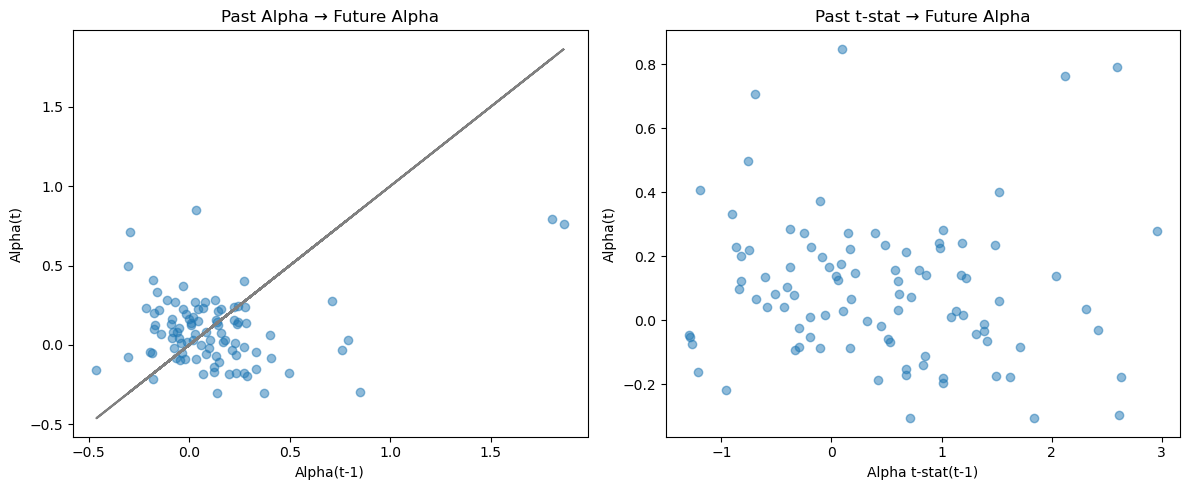

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(results_df.groupby('Ticker').shift(1)['Alpha'], results_df['Alpha'], 'o', alpha=0.5)
axes[0].plot(results_df['Alpha'], results_df['Alpha'], '-', color='grey')
axes[0].set_xlabel('Alpha(t-1)'); axes[0].set_ylabel('Alpha(t)')
axes[0].set_title('Past Alpha → Future Alpha')

axes[1].plot(results_df.groupby('Ticker').shift(1)['Alpha_Tstat'], results_df['Alpha'], 'o', alpha=0.5)
axes[1].set_xlabel('Alpha t-stat(t-1)'); axes[1].set_ylabel('Alpha(t)')
axes[1].set_title('Past t-stat → Future Alpha')

plt.tight_layout(); plt.show()

### Alpha Is Transient

- No predictive relationship — past alpha ≠ future alpha
- Even high t-stats don't predict higher future alpha
- Not surprising: everyone chases alpha, so it gets competed away quickly
- A crowded trade can yield **negative** alpha even if the original idea was right

### If Not Estimation, Then What?

**You need to think.** Three main edges:

**1. Valuation**
- Deep understanding of a business the market is mispricing
- Buffett, Einhorn (bet against Lehman)
- Edge = superior business judgment + knowing *why* the opportunity exists

**2. Liquidity provision**
- Forced sellers (fund outflows, index drops, credit downgrades) create reversals
- You take the other side — providing liquidity at a premium
- Edge = understanding that the price move is *not* about fundamentals

**3. Proprietary data**
- Satellite imagery of retail parking lots → predict sales
- Flow data, supply-chain data, weather data
- Edge = information that others don't yet have

### Quantifying Alpha

Put all views on a common horizon (e.g., monthly):

**Example:** You think NVDA (at \$1000) will be at \$800 in one year (−20%).
- Uniform timing: monthly $\alpha = (0.8)^{1/12} - 1 \approx -1.8\%$
- Known timing (last 2 earnings): $\alpha = 0$ for 6 months, then $(0.8)^{1/6} - 1 \approx -3.6\%$

**Important:** real alpha is *specific* — not a disguised macro bet.
- Bullish on tech? Buy the sector, not a single stock.
- Know exactly what your trade is and what risks you're exposed to.

## Key Takeaways

| What | Estimable? | How |
|------|-----------|-----|
| **Beta** | Yes | 1–2 yr daily regression; past $\beta$ predicts future $\beta$ |
| **Variance** | Yes | Rolling / realized variance; very persistent |
| **Factor premia** | Slowly | Long samples; precision grows only with *calendar time* |
| **Alpha** | No | Cannot be reliably estimated — requires an edge |

---

- Express alpha views at a consistent horizon before sizing positions
- Know your edge: valuation, liquidity provision, or proprietary data

## Appendix: The Normal Distribution

- Not required for factor estimation, but useful for statistical tests
- Reasonable approximation at monthly/annual frequency

Key facts for a standard normal $z$:
- 68% of draws within $\pm 1\sigma$
- 95% within $\pm 2\sigma$
- Standardization: $z = (x - \mu) / \sigma$

In [ ]:
# quantile → z-score
print(f"95th percentile z-score: {norm.ppf(0.95):.3f}")
# z-score → probability
print(f"CDF at z=1.645: {norm.cdf(1.645):.4f}")